In [3]:
from typing import TypedDict

class PortfolioState(TypedDict):
    totalAmt: float
    totalUSD: float
    totalINR: float




In [4]:
def calcTotalUSD(state: PortfolioState) -> PortfolioState:
    state["totalUSD"] = state["totalAmt"] * 1.08
    return state

def calcTotalINR(state: PortfolioState) -> PortfolioState:
    state["totalINR"] = state["totalUSD"] * 85
    return state

In [5]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)

builder.add_node("calcTotalUSD_node",calcTotalUSD)
builder.add_node("calcTotalINR_node",calcTotalINR)

builder.add_edge(START, "calcTotalUSD_node")
builder.add_edge("calcTotalUSD_node", "calcTotalINR_node")
builder.add_edge("calcTotalINR_node", END)

graph = builder.compile()

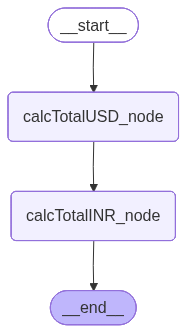

In [6]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
graph.invoke({"totalAmt": 1000})

{'totalAmt': 1000, 'totalUSD': 1080.0, 'totalINR': 91800.0}